In [1]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports

In [2]:
import polars as pl
import pandas as pd
import numpy as np
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

from typing import List

# Parameters

In [3]:
# Time boundaries (microseconds)
START_DATE = dt.datetime(2025, 12, 1, 0, 0, 0).timestamp() * 1_000_000
END_DATE   = dt.datetime(2025, 12, 7, 0, 0, 0).timestamp() * 1_000_000

SYMBOLS = ['btcusdt'] # ['btcusdt', 'ethusdt']
BASE_PATH = '/content/drive/MyDrive/CMF_HFT/liquidation_task'

# Data Downloading

In [4]:
def load_sym(sym):
    bin_trades = (pl.scan_parquet(f'{BASE_PATH}/data/binance_trades/perp_{sym}.parquet').
                  filter(pl.col('timestamp').is_between(START_DATE, END_DATE)))
    bin_bbo = (pl.scan_parquet(f'{BASE_PATH}/data/binance_booktickers/perp_{sym}.parquet').
                  filter(pl.col('timestamp').is_between(START_DATE, END_DATE)))
    bin_liq = (pl.scan_parquet(f'{BASE_PATH}/data/binance_liquidations/perp_{sym}.parquet').
                  filter(pl.col('timestamp').is_between(START_DATE, END_DATE)))
    byb_liq = (pl.scan_parquet(f'{BASE_PATH}/data/bybit_liquidations/{sym}.parquet').
                  filter(pl.col('timestamp').is_between(START_DATE, END_DATE)))

    return {
        'bin_trades': bin_trades,
        'bin_bbo': bin_bbo,
        'bin_liq': bin_liq,
        'byb_liq': byb_liq
    }

data = {sym: load_sym(sym) for sym in SYMBOLS}

# Sort by time
def check_monotonic(sym):
    for name, lf in data[sym].items():
        df = lf.collect()
        if df['timestamp'].is_sorted():
            print(f'{sym}_{name}: ✅ timestamp is monotonic')
        else:
            print(f'{sym}_{name}: ❌ timestamp is NOT monotonic – sorting')
            data[sym][name] = df.sort('timestamp').lazy()

print('\n=== Timestamp monotonicity check ===')
for sym in SYMBOLS:
    check_monotonic(sym)




=== Timestamp monotonicity check ===
btcusdt_bin_trades: ✅ timestamp is monotonic
btcusdt_bin_bbo: ✅ timestamp is monotonic
btcusdt_bin_liq: ✅ timestamp is monotonic
btcusdt_byb_liq: ❌ timestamp is NOT monotonic – sorting


In [5]:
# Quick preview
for sym in SYMBOLS:
    print(f'\n=== {sym} ===')
    for name, lf in data[sym].items():
        print(f'{name}: {lf.select(pl.len()).collect().item()} rows')



=== btcusdt ===
bin_trades: 27793996 rows
bin_bbo: 7026079 rows
bin_liq: 9704 rows
byb_liq: 17515 rows


# Data preparing

In [6]:
# Исходные LazyFrame
trades = data['btcusdt']['bin_trades']
bbo = data['btcusdt']['bin_bbo']
liq_bin = data['btcusdt']['bin_liq']
liq_byb = data['btcusdt']['byb_liq']

## Markout calculation

In [7]:
def add_mid(bbo_lf: pl.LazyFrame) -> pl.LazyFrame:
    return bbo_lf.with_columns(
        ((pl.col('bid_price') + pl.col('ask_price')) / 2).alias('mid')
    )

def add_notional(trades_lf: pl.LazyFrame) -> pl.LazyFrame:
    return trades_lf.with_columns(
        (pl.col('price') * pl.col('amount')).alias('notional')
    )

def compute_markout(
    trades_lf: pl.LazyFrame,
    bbo_lf: pl.LazyFrame,
    horizon_s: List[int] = [30, 120, 300],
) -> pl.LazyFrame:
    """
    Computes maker PnL (in bps) for each trade at multiple horizons.
    Formula: pnl = -sign * (mid(t+h) - price) / price * 10000 + 0.5
    sign = +1 for taker-buy (maker-sell), -1 for taker-sell (maker-buy).
    For each horizon h, a column pnl_{h} is added.
    If BBO at time t+h is missing, pnl_{h} = null.
    """
    # Prepare BBO
    bbo_mid = add_mid(bbo_lf).select('timestamp', 'mid').sort('timestamp')

    # Base LazyFrame with trades
    df = (
        trades_lf
        .pipe(add_notional)
        .sort('timestamp')
        .with_columns(
            sign=pl.when(pl.col('side') == 'buy')
                   .then(pl.lit(1))
                   .otherwise(pl.lit(-1))
        )
    )

    # For each horizon, do a separate asof join and save mid to a separate column
    for h in horizon_s:
        horizon_us = h * 1_000_000
        ts_future_col = f'ts_future_{h}'
        mid_col = f'mid_{h}'
        df = df.with_columns(
            (pl.col('timestamp') + horizon_us).alias(ts_future_col)
        )
        df = df.join_asof(
            bbo_mid,
            left_on=ts_future_col,
            right_on='timestamp',
            strategy='backward'
        )
        df = df.rename({'mid': mid_col})
        df = df.drop('timestamp_right')

    # Compute pnl for each horizon
    for h in horizon_s:
        mid_col = f'mid_{h}'
        pnl_col = f'pnl_{h}'
        df = df.with_columns(
            (
                -1
                * pl.col('sign')
                * (pl.col(mid_col) - pl.col('price'))
                / pl.col('price')
                * 10_000
                + 0.5
            ).alias(pnl_col)
        )

    # Add weight (common for all horizons)
    df = df.with_columns(
        weight=pl.col('notional').clip(upper_bound=100_000)
    )

    columns_to_drop = [
    'sign',
    'ts_future_30', 'mid_30',
    'ts_future_120', 'mid_120',
    'ts_future_300', 'mid_300']

    df = df.drop(columns_to_drop)

    return df


trades = compute_markout(trades, bbo)


In [8]:
trades.schema

Schema([('timestamp', Int64),
        ('ticker', String),
        ('side', String),
        ('price', Float64),
        ('amount', Float64),
        ('notional', Float64),
        ('pnl_30', Float64),
        ('pnl_120', Float64),
        ('pnl_300', Float64),
        ('weight', Float64)])

## Attach LOB and liquidations data to trades

In [9]:
# Join BBO (nearest below)
trades = trades.join_asof(
    bbo,
    on='timestamp',
    by='ticker',
    strategy='backward'
)

# Function to attach liquidations
def attach_liquidations(trades_lf, liq_lf, shift_us=0, prefix='bin'):
    # 1. Add index to trades
    trades_with_idx = trades_lf.with_row_index('trade_idx')

    # 2. Shift liquidation timestamps
    liq_shifted = liq_lf.with_columns(
        (pl.col('timestamp') + shift_us).alias('ts_shifted')
    )

    # 3. Prepare a small set of columns from trades for join_asof
    trades_idx_subset = trades_with_idx.select(['timestamp', 'trade_idx', 'ticker'])

    # 4. For each liquidation, find the index of the nearest future trade
    joined = liq_shifted.join_asof(
        trades_idx_subset,
        left_on='ts_shifted',
        right_on='timestamp',
        by='ticker',
        strategy='forward'   # take trade with timestamp >= ts_shifted
    )

    # 5. Add column price * amount for subsequent summation
    joined = joined.with_columns(
        (pl.col('price') * pl.col('amount')).alias('price_amount')
    )

    # 6. Aggregate sums by (trade_idx, side)
    agg = joined.group_by(['trade_idx', 'side']).agg([
        pl.col('price_amount').sum().alias('sum_price_amount'),
        pl.col('amount').sum().alias('sum_amount')
    ])

    # 7. Compute weighted price (avoid division by zero, but sum_amount is always >0)
    agg = agg.with_columns(
        (pl.col('sum_price_amount') / pl.col('sum_amount')).alias('weighted_price')
    )

    # 8. Split into buy and sell, rename columns
    agg_buy = agg.filter(pl.col('side') == 'buy').select([
        'trade_idx',
        pl.col('weighted_price').alias(f'{prefix}_liq_buy_price'),
        pl.col('sum_amount').alias(f'{prefix}_liq_buy_amount')
    ])

    agg_sell = agg.filter(pl.col('side') == 'sell').select([
        'trade_idx',
        pl.col('weighted_price').alias(f'{prefix}_liq_sell_price'),
        pl.col('sum_amount').alias(f'{prefix}_liq_sell_amount')
    ])

    # 9. Join aggregates to trades (left join)
    result = trades_with_idx.join(agg_buy, on='trade_idx', how='left')
    result = result.join(agg_sell, on='trade_idx', how='left')

    # 10. Fill missing values with zeros
    result = result.with_columns([
        pl.col(f'{prefix}_liq_buy_price').fill_null(0),
        pl.col(f'{prefix}_liq_buy_amount').fill_null(0),
        pl.col(f'{prefix}_liq_sell_price').fill_null(0),
        pl.col(f'{prefix}_liq_sell_amount').fill_null(0)
    ])

    # 11. Drop auxiliary index
    result = result.drop('trade_idx')

    return result

# Apply for Binance (shift 0)
trades = attach_liquidations(trades, liq_bin, shift_us=0, prefix='bin')

# Apply for Bybit (shift +200 ms = 200,000 µs)
trades = attach_liquidations(trades, liq_byb, shift_us=200_000, prefix='byb')

# Drop nulls
trades = trades.drop_nulls()


# Feature generation

In [10]:
def generate_features(trades: pl.LazyFrame) -> pl.LazyFrame:
    # Sort and add datetime
    trades = trades.sort("timestamp")
    trades = trades.with_columns(
        pl.from_epoch(pl.col("timestamp"), time_unit="us").alias("datetime")
    )

    # Base features (step by step to avoid references to new columns)
    trades = trades.with_columns(
        is_bin_liq=(pl.col("bin_liq_buy_price").is_not_null() | pl.col("bin_liq_sell_price").is_not_null()),
        is_byb_liq=(pl.col("byb_liq_buy_price").is_not_null() | pl.col("byb_liq_sell_price").is_not_null()),
        mid=(pl.col("ask_price") + pl.col("bid_price")) / 2.0,
        notional_trade=pl.col("price") * pl.col("amount"),
    )

    trades = trades.with_columns(
        is_trade=~(pl.col("is_bin_liq") | pl.col("is_byb_liq"))
    )

    trades = trades.with_columns(
        notional_trade_clean=pl.when(pl.col("is_trade")).then(pl.col("notional_trade")).otherwise(0.0),
        buy_amount=pl.when((pl.col("side") == "BUY") & pl.col("is_trade")).then(pl.col("amount")).otherwise(0.0),
        sell_amount=pl.when((pl.col("side") == "SELL") & pl.col("is_trade")).then(pl.col("amount")).otherwise(0.0),
        bin_liq_sell_notional=pl.when(pl.col("is_bin_liq")).then(pl.col("bin_liq_sell_price") * pl.col("bin_liq_sell_amount")).otherwise(0.0),
        bin_liq_buy_notional=pl.when(pl.col("is_bin_liq")).then(pl.col("bin_liq_buy_price") * pl.col("bin_liq_buy_amount")).otherwise(0.0),
        byb_liq_sell_notional=pl.when(pl.col("is_byb_liq")).then(pl.col("byb_liq_sell_price") * pl.col("byb_liq_sell_amount")).otherwise(0.0),
        byb_liq_buy_notional=pl.when(pl.col("is_byb_liq")).then(pl.col("byb_liq_buy_price") * pl.col("byb_liq_buy_amount")).otherwise(0.0),
    )

    # Aggregations over 10-second windows (without datetime column)
    agg_10s = (
        trades
        .group_by_dynamic("datetime", every="10s", period="10s", closed="left")
        .agg([
            pl.col("is_bin_liq").cast(pl.Int32).sum().alias("bin_liq_count_10s"),
            pl.col("is_byb_liq").cast(pl.Int32).sum().alias("byb_liq_count_10s"),
            pl.col("bin_liq_sell_notional").sum().alias("bin_liq_sell_notional_sum_10s"),
            pl.col("bin_liq_buy_notional").sum().alias("bin_liq_buy_notional_sum_10s"),
            pl.col("byb_liq_sell_notional").sum().alias("byb_liq_sell_notional_sum_10s"),
            pl.col("byb_liq_buy_notional").sum().alias("byb_liq_buy_notional_sum_10s"),
            pl.col("notional_trade_clean").sum().alias("notional_trade_sum_10s"),
            pl.col("buy_amount").sum().alias("buy_amount_sum_10s"),
            pl.col("sell_amount").sum().alias("sell_amount_sum_10s"),
        ])
        .with_columns(
            (pl.col("datetime") + pl.duration(seconds=10)).alias("window_end")
        )
        .select([
            pl.col("window_end"),
            pl.col("bin_liq_count_10s"),
            pl.col("byb_liq_count_10s"),
            pl.col("bin_liq_sell_notional_sum_10s"),
            pl.col("bin_liq_buy_notional_sum_10s"),
            pl.col("byb_liq_sell_notional_sum_10s"),
            pl.col("byb_liq_buy_notional_sum_10s"),
            pl.col("notional_trade_sum_10s"),
            pl.col("buy_amount_sum_10s"),
            pl.col("sell_amount_sum_10s"),
        ])
    )

    # Aggregations over 60-second windows (without datetime column)
    agg_60s = (
        trades
        .group_by_dynamic("datetime", every="60s", period="60s", closed="left")
        .agg([
            pl.col("mid").std().alias("mid_std_60s"),
        ])
        .with_columns(
            (pl.col("datetime") + pl.duration(seconds=60)).alias("window_end")
        )
        .select([
            pl.col("window_end"),
            pl.col("mid_std_60s"),
        ])
    )

    # Join aggregations (right tables do not contain "datetime" column, so no conflicts)
    trades = trades.join_asof(
        agg_10s,
        left_on="datetime",
        right_on="window_end",
        strategy="backward",
    )
    trades = trades.join_asof(
        agg_60s,
        left_on="datetime",
        right_on="window_end",
        strategy="backward",
    )

    # Fill nulls (first records)
    trades = trades.with_columns([
        pl.col("bin_liq_count_10s").fill_null(0),
        pl.col("byb_liq_count_10s").fill_null(0),
        pl.col("bin_liq_sell_notional_sum_10s").fill_null(0),
        pl.col("bin_liq_buy_notional_sum_10s").fill_null(0),
        pl.col("byb_liq_sell_notional_sum_10s").fill_null(0),
        pl.col("byb_liq_buy_notional_sum_10s").fill_null(0),
        pl.col("notional_trade_sum_10s").fill_null(0),
        pl.col("buy_amount_sum_10s").fill_null(0),
        pl.col("sell_amount_sum_10s").fill_null(0),
        pl.col("mid_std_60s").fill_null(0),
    ])

    # Binary features
    trades = trades.with_columns(
        spread_gt_0_5=(pl.col("ask_price") - pl.col("bid_price")) > 0.5,
        bin_liq_gt_5=pl.col("bin_liq_count_10s") > 1,
        byb_liq_gt_5=pl.col("byb_liq_count_10s") > 1,
        bin_liq_notional_gt_03=(pl.col("bin_liq_sell_notional_sum_10s") > 0.3) | (pl.col("bin_liq_buy_notional_sum_10s") > 5000),
        byb_liq_notional_gt_03=(pl.col("byb_liq_sell_notional_sum_10s") > 0.3) | (pl.col("byb_liq_buy_notional_sum_10s") > 5000),
        volatility_gt_0_000005=pl.col("mid_std_60s") > 0.000005,
        notional_trade_gt_2=pl.col("notional_trade_sum_10s") > 2,
    )

    # OFI
    epsilon = 1e-9
    trades = trades.with_columns(
        ofi_abs=((pl.col("buy_amount_sum_10s") - pl.col("sell_amount_sum_10s")).abs()
                 / (pl.col("buy_amount_sum_10s") + pl.col("sell_amount_sum_10s") + epsilon))
    )
    trades = trades.with_columns(
        ofi_gt_0_1=pl.col("ofi_abs") > 0.1
    )

    return trades

In [11]:
trades = generate_features(trades)

In [12]:
trades.schema

Schema([('timestamp', Int64),
        ('ticker', String),
        ('side', String),
        ('price', Float64),
        ('amount', Float64),
        ('notional', Float64),
        ('pnl_30', Float64),
        ('pnl_120', Float64),
        ('pnl_300', Float64),
        ('weight', Float64),
        ('bid_price', Float64),
        ('bid_amount', Float64),
        ('ask_price', Float64),
        ('ask_amount', Float64),
        ('bin_liq_buy_price', Float64),
        ('bin_liq_buy_amount', Float64),
        ('bin_liq_sell_price', Float64),
        ('bin_liq_sell_amount', Float64),
        ('byb_liq_buy_price', Float64),
        ('byb_liq_buy_amount', Float64),
        ('byb_liq_sell_price', Float64),
        ('byb_liq_sell_amount', Float64),
        ('datetime', Datetime(time_unit='us', time_zone=None)),
        ('is_bin_liq', Boolean),
        ('is_byb_liq', Boolean),
        ('mid', Float64),
        ('notional_trade', Float64),
        ('is_trade', Boolean),
        ('notional_trade_cle

In [13]:
# Sample for analysis
fraction = 0.01  # want 1% of data, ~ 300_000 rows

sample_lf = trades.filter(
    (pl.col('timestamp').hash() % 100) < (fraction * 100)
)

df = sample_lf.collect()  # now collect only ~1% of rows

In [14]:
df.head()

timestamp,ticker,side,price,amount,notional,pnl_30,pnl_120,pnl_300,weight,bid_price,bid_amount,ask_price,ask_amount,bin_liq_buy_price,bin_liq_buy_amount,bin_liq_sell_price,bin_liq_sell_amount,byb_liq_buy_price,byb_liq_buy_amount,byb_liq_sell_price,byb_liq_sell_amount,datetime,is_bin_liq,is_byb_liq,mid,notional_trade,is_trade,notional_trade_clean,buy_amount,sell_amount,bin_liq_sell_notional,bin_liq_buy_notional,byb_liq_sell_notional,byb_liq_buy_notional,window_end,bin_liq_count_10s,byb_liq_count_10s,bin_liq_sell_notional_sum_10s,bin_liq_buy_notional_sum_10s,byb_liq_sell_notional_sum_10s,byb_liq_buy_notional_sum_10s,notional_trade_sum_10s,buy_amount_sum_10s,sell_amount_sum_10s,window_end_right,mid_std_60s,spread_gt_0_5,bin_liq_gt_5,byb_liq_gt_5,bin_liq_notional_gt_03,byb_liq_notional_gt_03,volatility_gt_0_000005,notional_trade_gt_2,ofi_abs,ofi_gt_0_7
i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs],bool,bool,f64,f64,bool,f64,f64,f64,f64,f64,f64,f64,datetime[μs],i32,i32,f64,f64,f64,f64,f64,f64,f64,datetime[μs],f64,bool,bool,bool,bool,bool,bool,bool,f64,bool
1764547202246000,"""perp:btcusdt""","""buy""",90300.1,0.013,1173.9013,1.369324,5.721478,67.747988,1173.9013,90300.0,6.586,90300.1,6.158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-12-01 00:00:02.246,true,true,90300.05,1173.9013,false,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0.0,false,false,false,false,false,false,false,0.0,false
1764547207723000,"""perp:btcusdt""","""sell""",90265.1,0.078,7040.6778,6.931057,2.167311,-72.191439,7040.6778,90265.1,8.219,90265.2,2.537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-12-01 00:00:07.723,true,true,90265.15,7040.6778,false,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0.0,false,false,false,false,false,false,false,0.0,false
1764547207723000,"""perp:btcusdt""","""sell""",90265.1,0.06,5415.906,6.931057,2.167311,-72.191439,5415.906,90265.1,8.219,90265.2,2.537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-12-01 00:00:07.723,true,true,90265.15,5415.906,false,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0.0,false,false,false,false,false,false,false,0.0,false
1764547207723000,"""perp:btcusdt""","""sell""",90265.1,0.072,6499.0872,6.931057,2.167311,-72.191439,6499.0872,90265.1,8.219,90265.2,2.537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-12-01 00:00:07.723,true,true,90265.15,6499.0872,false,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0.0,false,false,false,false,false,false,false,0.0,false
1764547207723000,"""perp:btcusdt""","""sell""",90265.1,0.058,5235.3758,6.931057,2.167311,-72.191439,5235.3758,90265.1,8.219,90265.2,2.537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-12-01 00:00:07.723,true,true,90265.15,5235.3758,false,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,0.0,false,false,false,false,false,false,false,0.0,false


In [15]:
df.describe()

statistic,timestamp,ticker,side,price,amount,notional,pnl_30,pnl_120,pnl_300,weight,bid_price,bid_amount,ask_price,ask_amount,bin_liq_buy_price,bin_liq_buy_amount,bin_liq_sell_price,bin_liq_sell_amount,byb_liq_buy_price,byb_liq_buy_amount,byb_liq_sell_price,byb_liq_sell_amount,datetime,is_bin_liq,is_byb_liq,mid,notional_trade,is_trade,notional_trade_clean,buy_amount,sell_amount,bin_liq_sell_notional,bin_liq_buy_notional,byb_liq_sell_notional,byb_liq_buy_notional,window_end,bin_liq_count_10s,byb_liq_count_10s,bin_liq_sell_notional_sum_10s,bin_liq_buy_notional_sum_10s,byb_liq_sell_notional_sum_10s,byb_liq_buy_notional_sum_10s,notional_trade_sum_10s,buy_amount_sum_10s,sell_amount_sum_10s,window_end_right,mid_std_60s,spread_gt_0_5,bin_liq_gt_5,byb_liq_gt_5,bin_liq_notional_gt_03,byb_liq_notional_gt_03,volatility_gt_0_000005,notional_trade_gt_2,ofi_abs,ofi_gt_0_7
str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",278355.0,"""278355""","""278355""",278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,"""278355""",278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,"""278322""",278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,"""278291""",278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0,278355.0
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""33""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""64""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.7648e15,null,null,89866.625971,0.039143,3512.04857,-0.366655,-0.128413,-0.244878,3275.533175,89867.133852,6.216968,89867.425978,6.570601,14.600983,0.000018,18.269248,0.000022,0.0,0.0,0.0,0.0,"""2025-12-03 11:28:32.052989""",1.0,1.0,89867.279915,3512.04857,0.0,0.0,0.0,0.0,1.896374,1.62592,0.0,0.0,"""2025-12-03 11:28:52.628717""",1208.5715,1208.5715,6238.405011,2819.828455,0.0,0.0,0.0,0.0,0.0,"""2025-12-03 11:28:53.453471""",31.488878,0.048467,0.999881,0.999881,0.180428,0.0,0.999404,0.0,0.0,0.0
"""std""",1.4100e11,null,null,2778.916128,0.181679,16145.0277,7.260696,14.310992,21.494168,10783.822742,2778.807183,9.526136,2778.837489,17.567912,1148.89877,0.003194,1277.110712,0.006712,0.0,0.0,0.0,0.0,null,null,null,2778.822162,16145.0277,null,0.0,0.0,0.0,578.14953,282.912202,0.0,0.0,null,1657.799318,1657.799318,76658.754312,26616.469636,0.0,0.0,0.0,0.0,0.0,null,23.717172,null,null,null,null,null,null,null,0.0,null
"""min""",1.7645e15,"""perp:btcusdt""","""buy""",83789.4,0.001,83.8125,-59.76167,-99.61387,-149.981948,83.8125,83789.4,0.001,83789.5,0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""2025-12-01 00:00:02.246000""",1.0,1.0,83789.45,83.8125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""2025-12-01 00:00:10""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""2025-12-01 00:01:00""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",1.7646e15,null,null,87191.0,0.002,184.8896,-3.942668,-7.342088,-10.794771,184.8896,87190.9,0.672,87191.1,0.647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""2025-12-02 00:48:24.288000""",null,null,87190.95,184.8896,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""2025-12-02 00:50:20""",341.0,341.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""2025-12-02 00:51:00""",16.209797,null,null,null,null,null,null,null,0.0,null
"""50%""",1.7647e15,null,null,90453.8,0.003,274.2282,-0.319233,0.021909,-0.284025,274.2282,90450.2,3.929,90450.3,3.977,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""2025-12-03 07:11:01.500000""",null,null,90450.25,274.2282,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""2025-12-03 07:11:20""",688.0,688.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""2025-12-03 07:13:00""",25.241388,null,null,null,null,null,null,null,0.0,n

In [16]:
df.schema

Schema([('timestamp', Int64),
        ('ticker', String),
        ('side', String),
        ('price', Float64),
        ('amount', Float64),
        ('notional', Float64),
        ('pnl_30', Float64),
        ('pnl_120', Float64),
        ('pnl_300', Float64),
        ('weight', Float64),
        ('bid_price', Float64),
        ('bid_amount', Float64),
        ('ask_price', Float64),
        ('ask_amount', Float64),
        ('bin_liq_buy_price', Float64),
        ('bin_liq_buy_amount', Float64),
        ('bin_liq_sell_price', Float64),
        ('bin_liq_sell_amount', Float64),
        ('byb_liq_buy_price', Float64),
        ('byb_liq_buy_amount', Float64),
        ('byb_liq_sell_price', Float64),
        ('byb_liq_sell_amount', Float64),
        ('datetime', Datetime(time_unit='us', time_zone=None)),
        ('is_bin_liq', Boolean),
        ('is_byb_liq', Boolean),
        ('mid', Float64),
        ('notional_trade', Float64),
        ('is_trade', Boolean),
        ('notional_trade_cle

# Visualization

In [17]:
# avg_pnl_30_all = df['pnl_30'].mean()
# avg_pnl_120_all = df['pnl_120'].mean()
# avg_pnl_300_all = df['pnl_300'].mean()

## Main visualization function

In [18]:
def plot_single_feature(df, feature_name, figsize=(12, 5)):
    """
    Builds two barplots for a given binary feature:
      1. Average PnL for three time horizons (30, 120, 300 s) for True/False groups.
      2. Total notional by groups with percentage breakdown.
    The feature name is displayed on the plots.

    Parameters:
        df : pl.DataFrame or pd.DataFrame
            Source data with columns pnl_30, pnl_120, pnl_300, notional and feature_name.
        feature_name : str
            Name of the binary column (type bool or Int8/Int16 with 0/1).
        figsize : tuple, optional
            Figure size (width, height).
    """
    # Convert Polars → Pandas for convenient work with seaborn
    if isinstance(df, pl.DataFrame):
        df_pd = df.to_pandas()
    else:
        df_pd = df.copy()

    if feature_name not in df_pd.columns:
        print(f"Column '{feature_name}' not found in data.")
        return

    # Group by binary feature value
    grouped = df_pd.groupby(feature_name).agg(
        mean_pnl_30=('pnl_30', 'mean'),
        mean_pnl_120=('pnl_120', 'mean'),
        mean_pnl_300=('pnl_300', 'mean'),
        sum_notional=('notional', 'sum')
    ).reset_index()

    # Notional percentage breakdown
    total_notional = grouped['sum_notional'].sum()
    grouped['notional_percent'] = grouped['sum_notional'] / total_notional * 100

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # 1. Average PnL (grouped bars by horizon)
    pnl_melt = grouped.melt(
        id_vars=[feature_name],
        value_vars=['mean_pnl_30', 'mean_pnl_120', 'mean_pnl_300'],
        var_name='horizon',
        value_name='mean_pnl'
    )
    horizon_labels = {'mean_pnl_30': '30s', 'mean_pnl_120': '120s', 'mean_pnl_300': '300s'}
    pnl_melt['horizon'] = pnl_melt['horizon'].map(horizon_labels)

    sns.barplot(data=pnl_melt, x=feature_name, y='mean_pnl', hue='horizon', ax=axes[0])
    axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[0].set_title(f'Average PnL by feature: {feature_name}')
    axes[0].set_ylabel('Average PnL')
    axes[0].legend(title='Horizon')

    # 2. Total notional with percentages
    sns.barplot(data=grouped, x=feature_name, y='sum_notional', ax=axes[1], color='skyblue')
    axes[1].set_title(f'Total notional by feature: {feature_name}')
    axes[1].set_ylabel('Total notional')

    # Percentage labels on bars
    max_notional = grouped['sum_notional'].max()
    for i, row in grouped.iterrows():
        axes[1].text(
            i,
            row['sum_notional'] + 0.05 * max_notional,
            f"{row['notional_percent']:.1f}%",
            ha='center', va='bottom', fontweight='bold'
        )

    # Adjust X-axis labels (if boolean values)
    if grouped[feature_name].dtype == bool:
        axes[0].set_xticklabels(['False', 'True'])
        axes[1].set_xticklabels(['False', 'True'])
    else:
        # If 0/1, can label explicitly
        unique_vals = sorted(grouped[feature_name].unique())
        labels = [str(v) for v in unique_vals]
        axes[0].set_xticklabels(labels)
        axes[1].set_xticklabels(labels)

    plt.tight_layout()
    plt.show()

## Spread

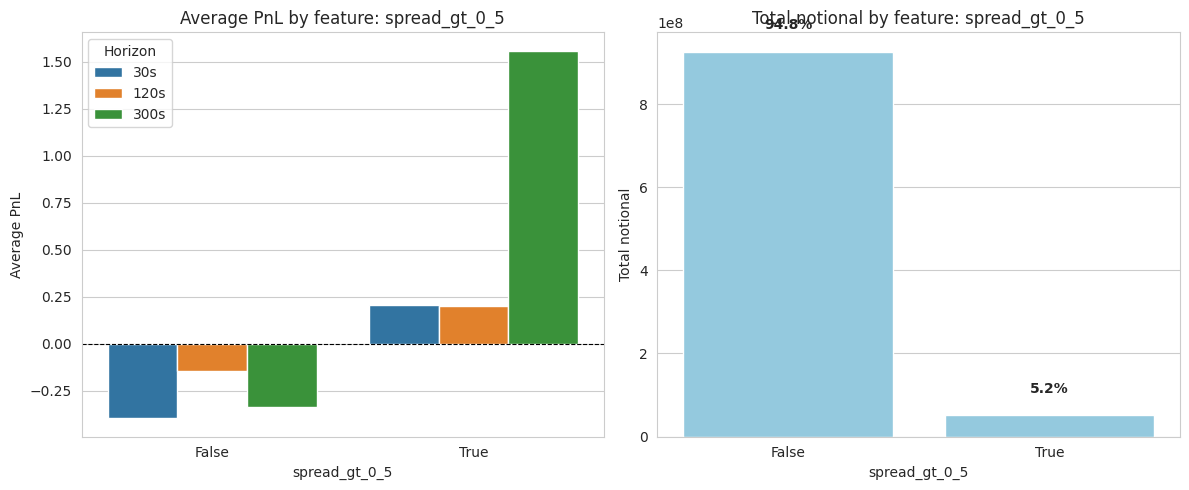

In [19]:
plot_single_feature(df, 'spread_gt_0_5')

## Binance liquidations

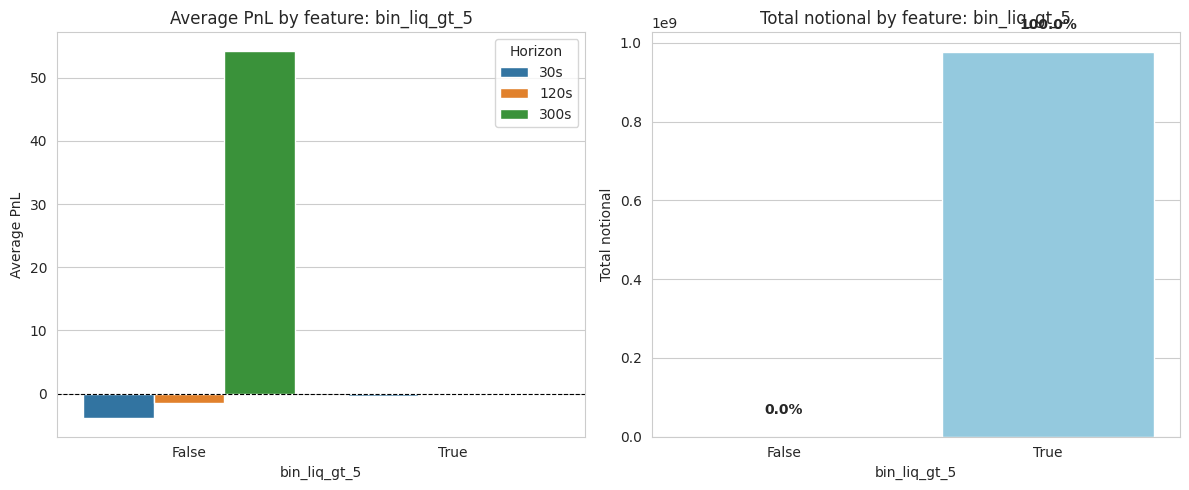

In [20]:
plot_single_feature(df, 'bin_liq_gt_5')

## Bybit liquidations

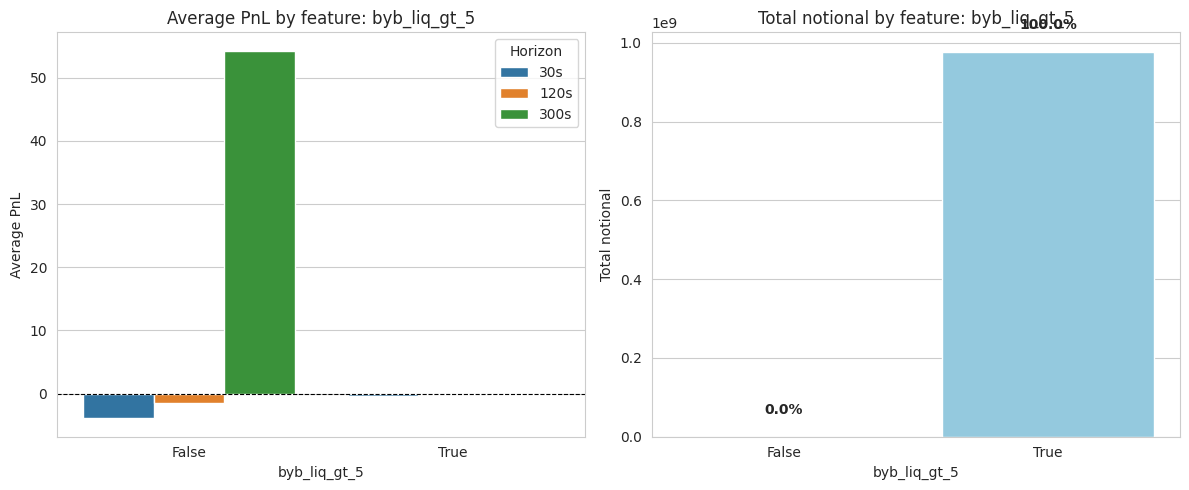

In [21]:
plot_single_feature(df, 'byb_liq_gt_5')

## Binance liquidations

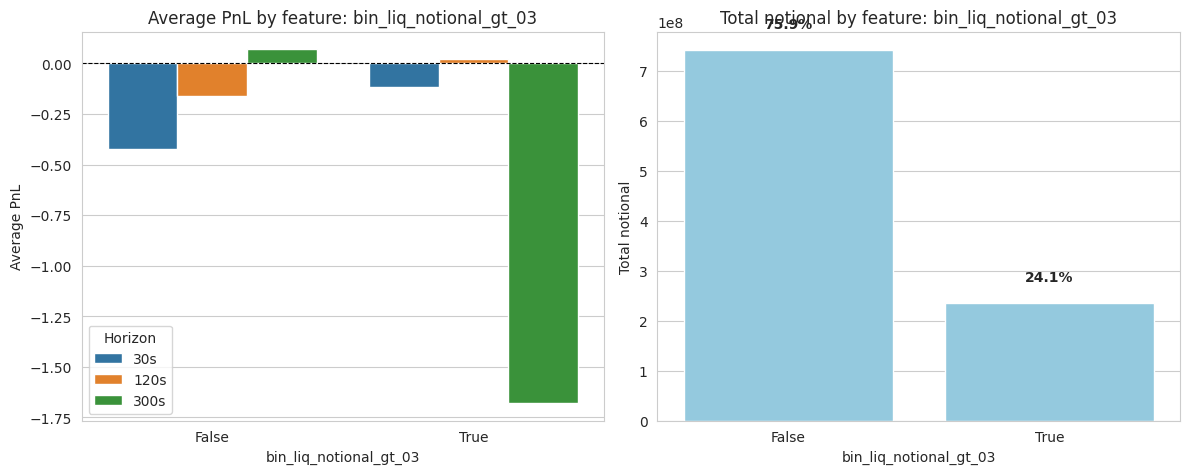

In [28]:
plot_single_feature(df, 'bin_liq_notional_gt_03')

## Bybit liquidations

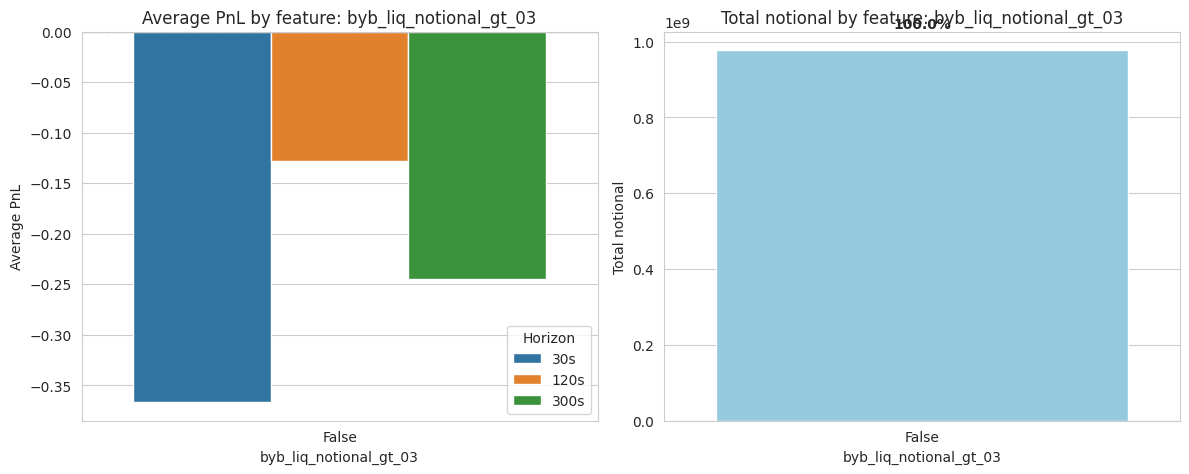

In [29]:
plot_single_feature(df, 'byb_liq_notional_gt_03')

## Trades notional

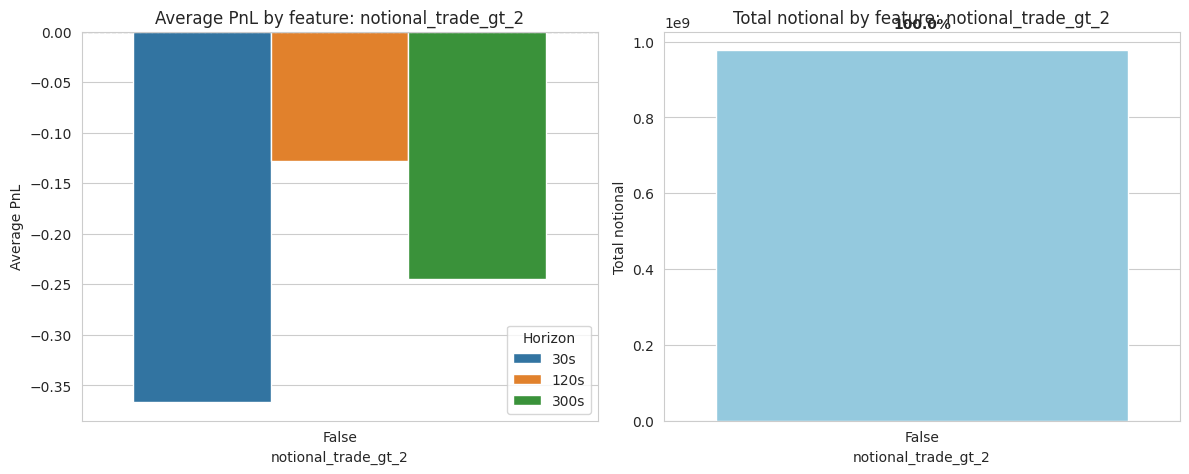

In [32]:
plot_single_feature(df, 'notional_trade_gt_2')

## OFI

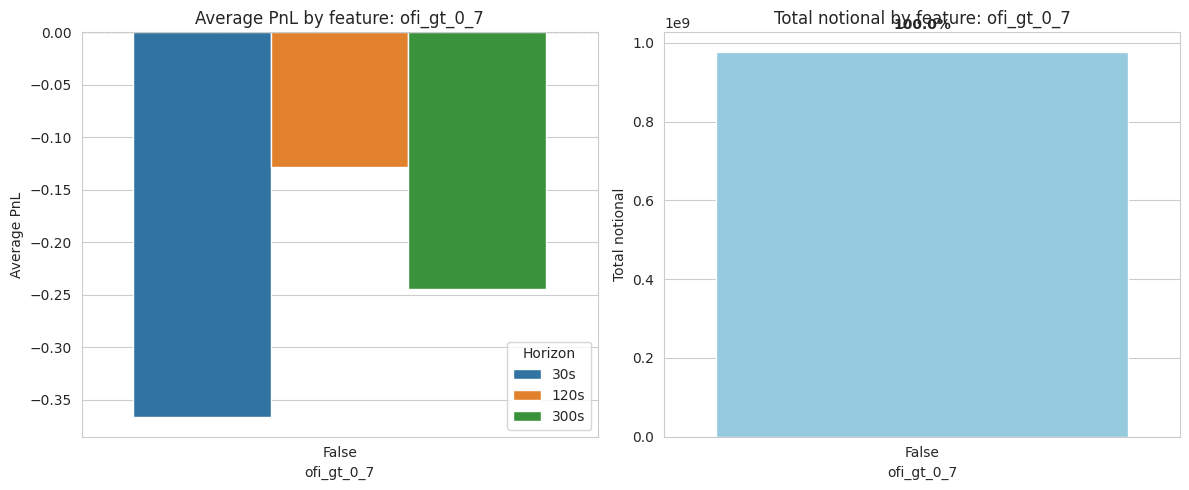

In [34]:
plot_single_feature(df, 'ofi_gt_0_7')

## Volatility

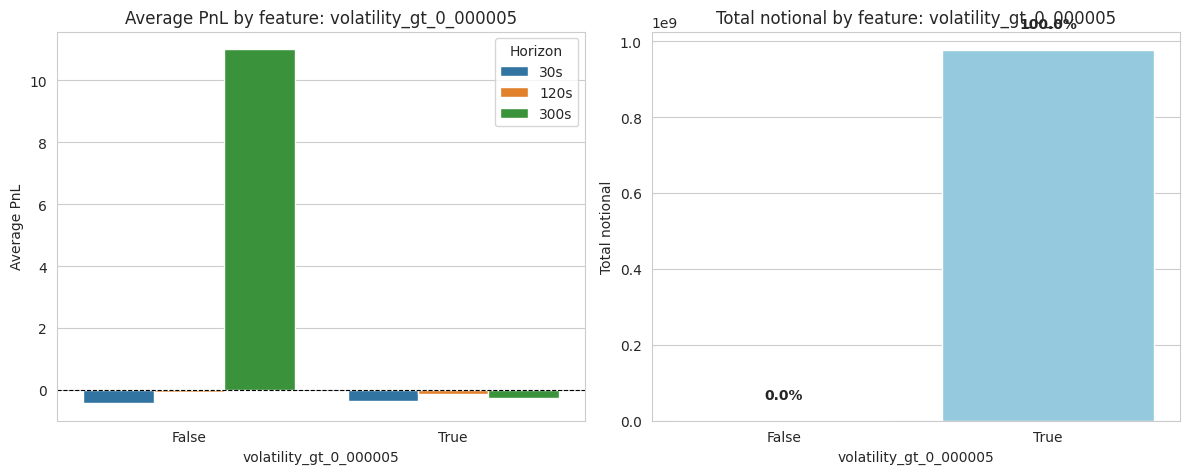

In [27]:
plot_single_feature(df, 'volatility_gt_0_000005')

# Summary

Future improvements:
- In this work, the thresholds for binary filters were chosen very poorly; this needs to be done much more carefully. Currently, due to poor threshold selection, some filters failed to produce 2 distinct values.
- Also, in addition to adding "univariate" features, you can add combination features of several other features (e.g., wide spread & high volatility).
- Some features are meaningless to use because their notional is too small and will not be stable across different market regimes.